<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/marketing_Mix_Models/MMM%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas statsmodels matplotlib scipy


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     7260.
Date:                Wed, 05 Feb 2025   Prob (F-statistic):               0.00
Time:                        08:13:37   Log-Likelihood:                -15513.
No. Observations:                3000   AIC:                         3.104e+04
Df Residuals:                    2991   BIC:                         3.110e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                678.5705      4

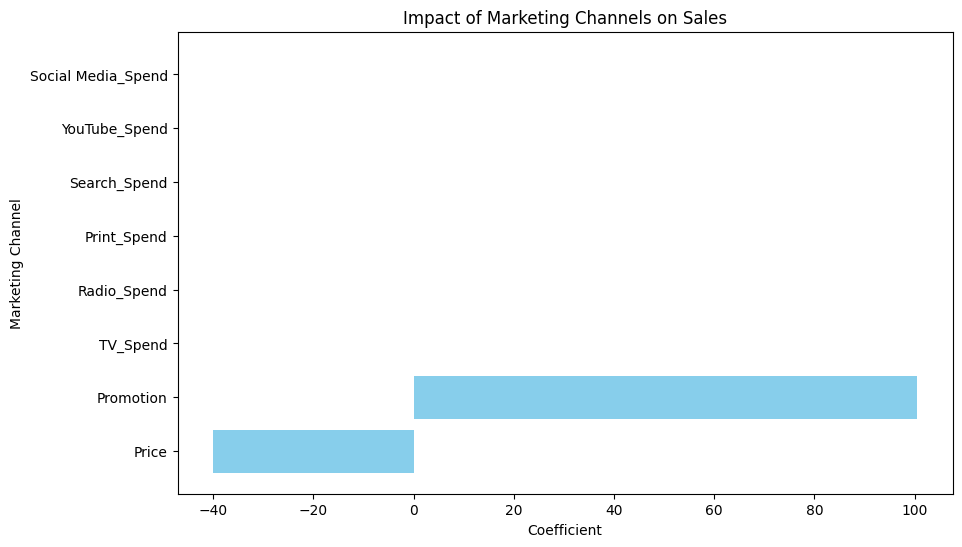

Optimized budget allocation:
TV: 0.00
Radio: 0.00
Print: 0.00
Search: 30000.00
YouTube: 0.00
Social Media: 0.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize

# Load the dataset from CSV file
df = pd.read_csv('/content/MMM brand data.csv')

# Define the independent variables (marketing spends) and dependent variable (Sales)
X = df[['Price', 'Promotion', 'TV_Spend', 'Radio_Spend', 'Print_Spend', 'Search_Spend', 'YouTube_Spend', 'Social Media_Spend']]
y = df['Sales']

# Add a constant to the independent variables matrix for the intercept term
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the model summary to check the coefficients and R-squared value
print(model.summary())

# Visualize the impact of each marketing channel on sales
coefficients = model.params[1:]  # Exclude constant
channels = X.columns[1:]  # Exclude constant

# Plot the coefficients as a bar chart
plt.figure(figsize=(10, 6))
plt.barh(channels, coefficients, color='skyblue')
plt.xlabel('Coefficient')
plt.ylabel('Marketing Channel')
plt.title('Impact of Marketing Channels on Sales')
plt.show()

# Optimization of budget allocation using a simple linear model
# Define the objective function for optimization (minimize the negative sales prediction)
def objective_function(budgets):
    # Reconstruct the marketing spends from the budget values
    tv_spend, radio_spend, print_spend, search_spend, youtube_spend, social_spend = budgets
    # Use the model to predict sales based on the budget allocation
    predicted_sales = model.predict([1, 14, 0, tv_spend, radio_spend, print_spend, search_spend, youtube_spend, social_spend])
    # Return the negative predicted sales (because we want to maximize it)
    return -predicted_sales

# Budget constraints (assume a total budget of $30,000 and budget for each channel should be non-negative)
constraints = (
    {'type': 'eq', 'fun': lambda x: sum(x) - 30000},  # Total budget should be 30,000
)

# Initial budget allocation (evenly distributed)
initial_budget = [5000] * 6

# Perform the optimization
result = minimize(objective_function, initial_budget, constraints=constraints, bounds=[(0, None)] * 6)

# Print the optimized budget allocation
if result.success:
    print(f"Optimized budget allocation:\nTV: {result.x[0]:.2f}\nRadio: {result.x[1]:.2f}\nPrint: {result.x[2]:.2f}\nSearch: {result.x[3]:.2f}\nYouTube: {result.x[4]:.2f}\nSocial Media: {result.x[5]:.2f}")
else:
    print("Optimization failed!")


Intercept: 678.6176847471993
Coefficients: [-4.00863285e+01  1.00395097e+02  7.12597046e-03  1.00287448e-02
  8.18641131e-03  3.10946603e-02  8.56178240e-03  1.65198803e-02]


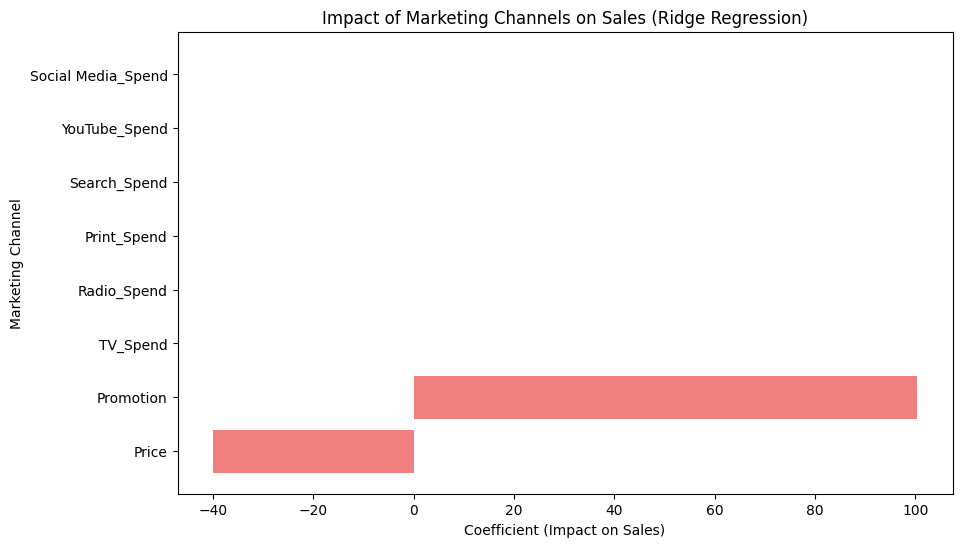

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does n

Optimized Budget Allocation (Total Budget = $30,000):
TV: $0.00
Radio: $0.00
Print: $0.00
Search: $15000.00
YouTube: $0.00
Social Media: $15000.00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does n

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from scipy.optimize import minimize

# Load your data from CSV file
df = pd.read_csv('/content/MMM brand data.csv')

# Define independent variables (marketing spend data) and dependent variable (Sales)
X = df[['Price', 'Promotion', 'TV_Spend', 'Radio_Spend', 'Print_Spend', 'Search_Spend', 'YouTube_Spend', 'Social Media_Spend']]
y = df['Sales']

# Ridge Regression (Lightweight MMM)
ridge_model = Ridge(alpha=1.0)  # Regularization strength, higher alpha -> more regularization
ridge_model.fit(X, y)

# Print coefficients and intercept
print(f"Intercept: {ridge_model.intercept_}")
print(f"Coefficients: {ridge_model.coef_}")

# Visualize the impact of each marketing channel on sales
coefficients = ridge_model.coef_
channels = X.columns

# Create a bar plot to visualize the coefficients (impact of each marketing channel)
plt.figure(figsize=(10, 6))
plt.barh(channels, coefficients, color='lightcoral')
plt.xlabel('Coefficient (Impact on Sales)')
plt.ylabel('Marketing Channel')
plt.title('Impact of Marketing Channels on Sales (Ridge Regression)')
plt.show()

# Optimization of budget allocation: Optimize for maximum sales prediction
def objective_function(budgets):
    # Extract marketing spend values from optimized budgets
    tv_spend, radio_spend, print_spend, search_spend, youtube_spend, social_spend = budgets
    # Use the Ridge model to predict sales for the given budget allocation (constant price and promotion values)
    predicted_sales = ridge_model.predict([[14, 0, tv_spend, radio_spend, print_spend, search_spend, youtube_spend, social_spend]])
    # Return the negative predicted sales because we want to maximize sales
    return -predicted_sales[0]

# Budget constraints: Total budget must be fixed (e.g., $30,000), no negative budget allocation
constraints = (
    {'type': 'eq', 'fun': lambda x: sum(x) - 30000},  # Total budget constraint (should sum to 30,000)
)

# Initial budget allocation (equal allocation among channels)
initial_budget = [5000] * 6

# Perform optimization to find the optimal budget allocation using minimize function
result = minimize(objective_function, initial_budget, constraints=constraints, bounds=[(0, 15000)] * 6)  # Bound each channel's budget between 0 and 15000

# Output optimized budget allocation
if result.success:
    print(f"Optimized Budget Allocation (Total Budget = $30,000):")
    print(f"TV: ${result.x[0]:.2f}")
    print(f"Radio: ${result.x[1]:.2f}")
    print(f"Print: ${result.x[2]:.2f}")
    print(f"Search: ${result.x[3]:.2f}")
    print(f"YouTube: ${result.x[4]:.2f}")
    print(f"Social Media: ${result.x[5]:.2f}")
else:
    print("Optimization failed!")


                        Week     Price  Promotion     Sales  TV_Spend  \
Week                1.000000 -0.001011  -0.010676  0.010146  0.010732   
Price              -0.001011  1.000000  -0.028358 -0.906740 -0.012123   
Promotion          -0.010676 -0.028358   1.000000  0.269437 -0.018561   
Sales               0.010146 -0.906740   0.269437  1.000000  0.067618   
TV_Spend            0.010732 -0.012123  -0.018561  0.067618  1.000000   
Radio_Spend         0.013780  0.024178   0.006692  0.039280 -0.005438   
Print_Spend        -0.012419  0.001034  -0.007156  0.050752  0.023769   
Search_Spend        0.005042  0.013701   0.008738  0.198726  0.043597   
YouTube_Spend       0.010483 -0.008463   0.001652  0.066217 -0.004951   
Social Media_Spend  0.018410 -0.017036  -0.001119  0.126771  0.025766   

                    Radio_Spend  Print_Spend  Search_Spend  YouTube_Spend  \
Week                   0.013780    -0.012419      0.005042       0.010483   
Price                  0.024178     0.0010

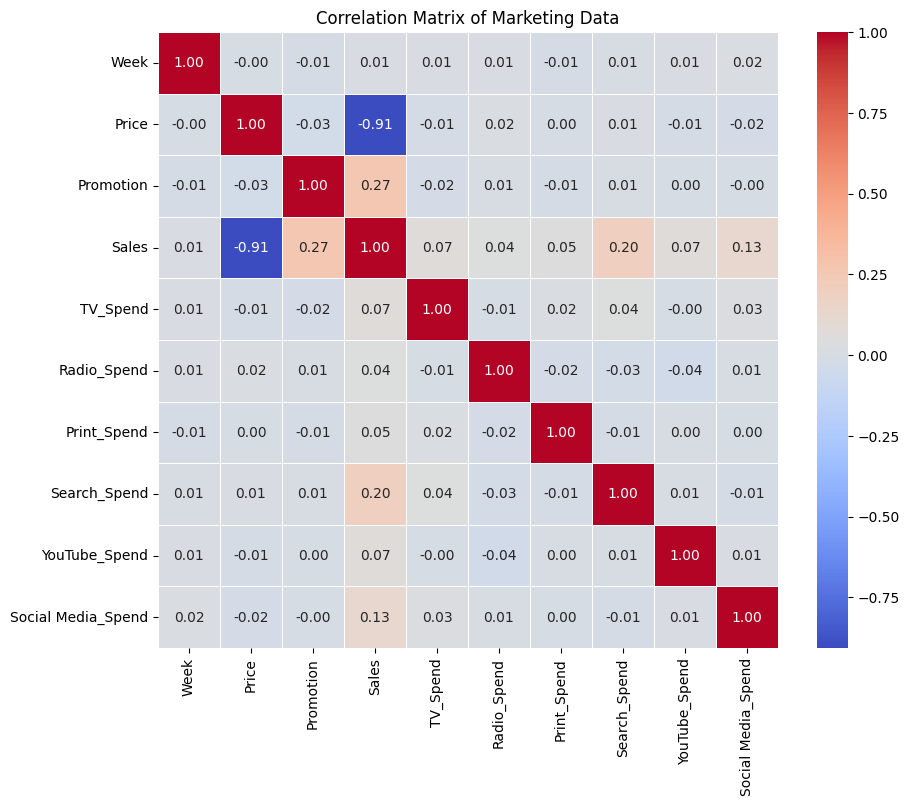

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data from CSV file
df = pd.read_csv('/content/MMM brand data.csv')

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Marketing Data')
plt.show()
